# ASAP-SAS : Scoring Automatique de Réponses Courtes

**Objectif** : Développer un modèle de classification multi-classes pour prédire automatiquement le score d'une réponse courte d'étudiant.

**Métriques d'évaluation** : Quadratic Weighted Kappa (QWK) + Accuracy

**État de l'art à battre** : BERT (Mean QWK = 0.71)

---
## 1. Importation des Bibliothèques

In [ ]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Prétraitement et métriques
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight

# Sentence-BERT pour embeddings
from sentence_transformers import SentenceTransformer

# PyTorch pour le modèle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Configuration
plt.style.use('default')
sns.set_palette("husl")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device : {device}")

✅ Device : cuda


---
## 2. Chargement des Données

*Charger le fichier depuis Drive (À CHAQUE SESSION)*

In [ ]:
import pandas as pd

train_path = "/content/drive/MyDrive/ASAP_SAS/train.tsv"

df = pd.read_csv(train_path, sep='\t', encoding='latin-1')


In [ ]:
print(f" Dataset: {df.shape[0]} réponses, {df.shape[1]} colonnes")
print(f"\n Colonnes: {list(df.columns)}")
df.head(10)

 Dataset: 17207 réponses, 5 colonnes

 Colonnes: ['Id', 'EssaySet', 'Score1', 'Score2', 'EssayText']


,Id,EssaySet,Score1,Score2,EssayText
0,1,1,1,1,Some additional information that we would need...
1,2,1,1,1,"After reading the expirement, I realized that ..."
2,3,1,1,1,"What you need is more trials, a control set up..."
3,4,1,0,0,The student should list what rock is better an...
4,5,1,2,2,For the students to be able to make a replicat...
5,6,1,1,0,I would need the information of why you would ...
6,7,1,1,0,The information I would need in order to suces...
7,8,1,3,3,You would need many more pieces of information...
8,9,1,3,3,Some additional information you will need are ...
9,10,1,2,2,"Inorder to replicate the experiment, we will n..."


In [ ]:
# Informations générales
print(" Informations du dataset:")
df.info()
print("\n Valeurs manquantes:")
df.isnull().sum()

 Informations du dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17207 entries, 0 to 17206
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         17207 non-null  int64 
 1   EssaySet   17207 non-null  int64 
 2   Score1     17207 non-null  int64 
 3   Score2     17207 non-null  int64 
 4   EssayText  17207 non-null  object
dtypes: int64(4), object(1)
memory usage: 672.3+ KB

 Valeurs manquantes:


,0
Id,0
EssaySet,0
Score1,0
Score2,0
EssayText,0


---
## 3. Exploration des Données (EDA)

Nous allons analyser la distribution des scores, les longueurs de réponses et les particularités par question.

In [ ]:
# Calcul de la longueur des réponses
df['answer_length'] = df['EssayText'].apply(lambda x: len(str(x).split()))
print("- Statistiques sur la longueur des réponses (en mots):")
print(df['answer_length'].describe())

- Statistiques sur la longueur des réponses (en mots):
count    17207.000000
mean        42.354391
std         27.197818
min          1.000000
25%         23.000000
50%         39.000000
75%         56.000000
max        325.000000
Name: answer_length, dtype: float64


### 3.1 Choix du Score de Référence

Dans ce projet, nous utilisons **`Score1` comme score final**, car il correspond à la note officielle attribuée à l’essai et c’est celle que le modèle doit prédire.
**`Score2`** sert uniquement à vérifier l’accord entre les correcteurs et n’est pas utilisé pour l’entraînement.

In [ ]:
# Corrélation entre Score1 et Score2
def quadratic_weighted_kappa(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')

qwk_inter = quadratic_weighted_kappa(df['Score1'], df['Score2'])
print(f"- QWK entre Score1 et Score2: {qwk_inter:.3f}")

- QWK entre Score1 et Score2: 0.913


 Le faite que QWK = 0.913 (proche de 1) indique un accord élevé entre les deux évaluateurs humains, ce qui valide la cohérence du dataset.


### 3.2 Distribution Globale des Scores

**Observation** : Déséquilibre des classes détecté (Score 3 est minoritaire)

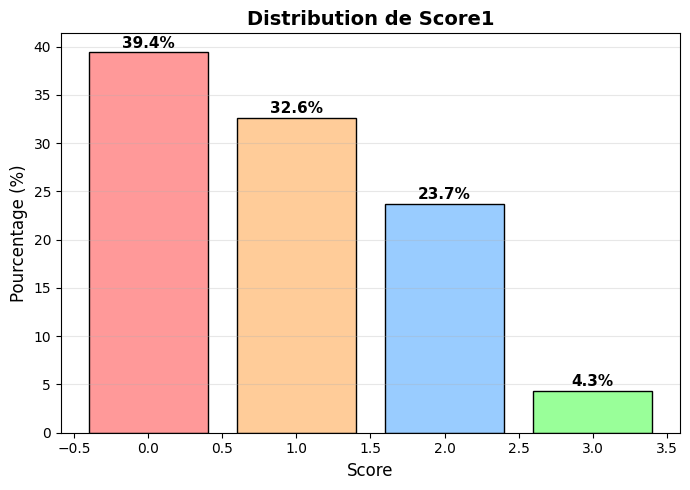


-> Déséquilibre des classes:
   Score 0:  6779 exemples ( 39.4%)
   Score 1:  5612 exemples ( 32.6%)
   Score 2:  4075 exemples ( 23.7%)
   Score 3:   741 exemples (  4.3%)


In [ ]:
# Visualisation de la distribution
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

# Distribution avec pourcentages
score_pct = (df['Score1'].value_counts(normalize=True)
             .sort_index() * 100).round(1)

colors = ['#ff9999', '#ffcc99', '#99ccff', '#99ff99']
bars = ax.bar(
    score_pct.index,
    score_pct.values,
    color=colors[:len(score_pct)],
    edgecolor='black'
)

ax.set_xlabel('Score', fontsize=12)
ax.set_ylabel('Pourcentage (%)', fontsize=12)
ax.set_title('Distribution de Score1', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Affichage des pourcentages
for bar, pct in zip(bars, score_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{pct}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

print(f"\n-> Déséquilibre des classes:")
for score in sorted(df['Score1'].unique()):
    count = (df['Score1'] == score).sum()
    pct = count / len(df) * 100
    print(f"   Score {score}: {count:5d} exemples ({pct:5.1f}%)")


**Point important** : Nous observons que les scores ne sont pas équilibrés. Les scores 0, 1, et 2 sont beaucoup plus fréquents que le score 3. Ce déséquilibre sera pris en compte lors de l'entraînement grâce au **class weighting**.

### 3.3 Distribution par Question

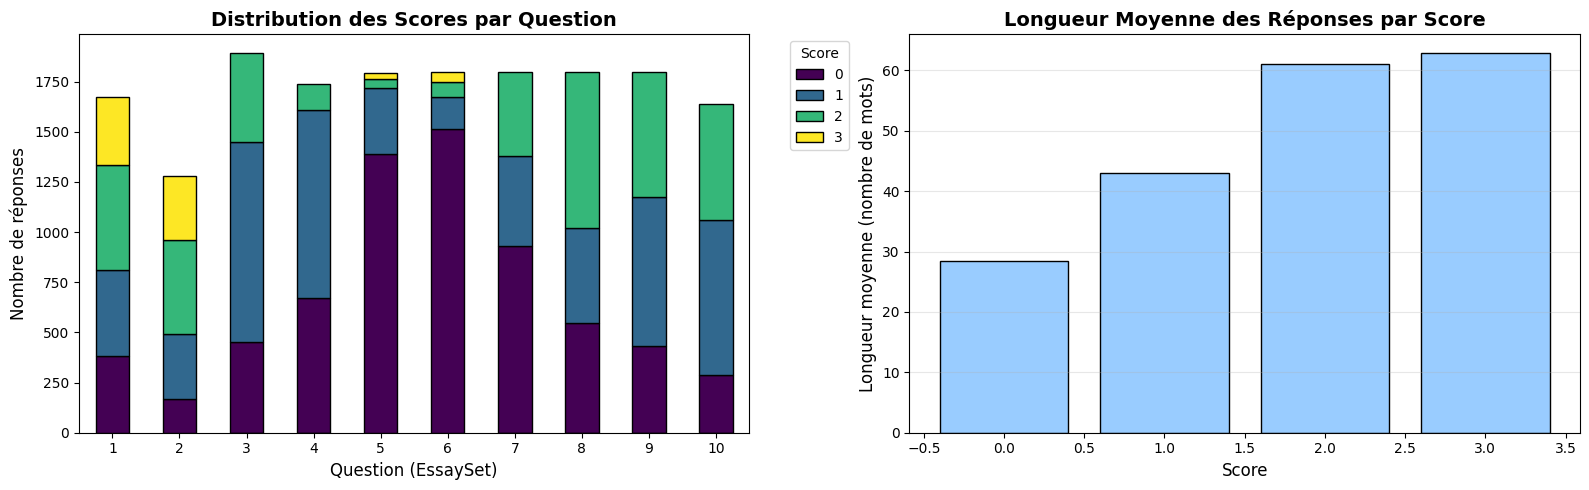


- Classes disponibles par question:
   Question  1: 4 classes
   Question  2: 4 classes
   Question  3: 3 classes
   Question  4: 3 classes
   Question  5: 4 classes
   Question  6: 4 classes
   Question  7: 3 classes
   Question  8: 3 classes
   Question  9: 3 classes
   Question 10: 3 classes


In [ ]:
# Distribution des scores par question
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1️⃣ Stacked bar chart (INCHANGÉ)
score_by_question = df.groupby(['EssaySet', 'Score1']).size().unstack(fill_value=0)
score_by_question.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    colormap='viridis',
    edgecolor='black'
)

axes[0].set_xlabel('Question (EssaySet)', fontsize=12)
axes[0].set_ylabel('Nombre de réponses', fontsize=12)
axes[0].set_title('Distribution des Scores par Question', fontsize=14, fontweight='bold')
axes[0].legend(title='Score', bbox_to_anchor=(1.05, 1))
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# 2️⃣ Longueur moyenne par score (REMPLACE le boxplot)
mean_length = df.groupby('Score1')['answer_length'].mean()

axes[1].bar(
    mean_length.index,
    mean_length.values,
    color='#99ccff',
    edgecolor='black'
)

axes[1].set_xlabel('Score', fontsize=12)
axes[1].set_ylabel('Longueur moyenne (nombre de mots)', fontsize=12)
axes[1].set_title('Longueur Moyenne des Réponses par Score', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Analyse du nombre de classes par question
print("\n- Classes disponibles par question:")
for q in range(1, 11):
    scores = sorted(df[df['EssaySet'] == q]['Score1'].unique())
    n_classes = len(scores)
    print(f"   Question {q:2d}: {n_classes} classes")


 **Interprétation**

La longueur moyenne des réponses **augmente avec le score**, ce qui indique que les réponses plus longues tendent à obtenir de meilleures notes.  
Cependant, la longueur seule n’est pas suffisante et doit être combinée avec d’autres caractéristiques textuelles.

Le nombre de classes varie selon les questions : certaines ont **4 classes de score**, tandis que d’autres n’en ont que **3**.  
Cette variation montre que la **question (EssaySet)** doit être prise en compte lors de la modélisation.







---
## 4. Prétraitement des Données

**Philosophie** : Nettoyage minimal pour préserver les erreurs des étudiants (indicateurs de qualité)

In [ ]:
def clean_text(text):
    """
    Nettoyage léger du texte:
    - Normalisation des espaces
    - Suppression des caractères spéciaux inutiles
    - Préservation de la ponctuation et de la structure
    """
    text = str(text).strip()
    text = re.sub(r'\s+', ' ', text)  # Espaces multiples → 1 espace
    text = re.sub(r'[^a-zA-Z0-9\s.,!?\'\"\-]', '', text)  # Garder ponctuation de base
    return text

# Application du prétraitement
df['EssayText_clean'] = df['EssayText'].apply(clean_text)

print("✅ Prétraitement appliqué")
print("\nExemple de transformation:")
print("AVANT:", df['EssayText'].iloc[0][:100])
print("APRÈS:", df['EssayText_clean'].iloc[0][:100])

✅ Prétraitement appliqué

Exemple de transformation:
AVANT: Some additional information that we would need to replicate the experiment is how much vinegar shoul
APRÈS: Some additional information that we would need to replicate the experiment is how much vinegar shoul


### 4.1 Préparation de la Variable Cible

In [ ]:
# Les scores vont de 0 à 3, parfait pour classification multi-classes
df['target'] = df['Score1']
num_classes = df['target'].nunique()
print(f"📊 Nombre de classes: {num_classes}")
print(f"   Classes: {sorted(df['target'].unique())}")

📊 Nombre de classes: 4
   Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


---
## 5. Split des Données (70% / 15% / 15%)

**Stratification** : Préserver la distribution des scores dans chaque ensemble

In [ ]:
# Split stratifié
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['target'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['target'])

print("- Répartition des données:")
print(f"   Train: {len(train_df):5d} ({len(train_df)/len(df)*100:.1f}%)")
print(f"   Val:   {len(val_df):5d} ({len(val_df)/len(df)*100:.1f}%)")
print(f"   Test:  {len(test_df):5d} ({len(test_df)/len(df)*100:.1f}%)")

print("\n✅ Distribution préservée (stratification):")
print("\nTrain:")
print(train_df['target'].value_counts(normalize=True).sort_index().round(3))
print("\nTest:")
print(test_df['target'].value_counts(normalize=True).sort_index().round(3))

- Répartition des données:
   Train: 12044 (70.0%)
   Val:    2581 (15.0%)
   Test:   2582 (15.0%)

✅ Distribution préservée (stratification):

Train:
target
0    0.394
1    0.326
2    0.237
3    0.043
Name: proportion, dtype: float64

Test:
target
0    0.394
1    0.326
2    0.237
3    0.043
Name: proportion, dtype: float64


---
## 6. Encodage avec Sentence-BERT

**Modèle** : `all-mpnet-base-v2` (768 dimensions)
- Meilleur modèle Sentence-BERT pour tâches générales
- Pré-entraîné sur 1 milliard de paires de phrases

In [ ]:
# Chargement du modèle
print(" Chargement de Sentence-BERT...")
sbert_model = SentenceTransformer('all-mpnet-base-v2')
print("✅ Modèle chargé: all-mpnet-base-v2")

# Génération des embeddings
print("\n Génération des embeddings...")
X_train = sbert_model.encode(train_df['EssayText_clean'].tolist(), show_progress_bar=True, batch_size=32)
X_val = sbert_model.encode(val_df['EssayText_clean'].tolist(), show_progress_bar=True, batch_size=32)
X_test = sbert_model.encode(test_df['EssayText_clean'].tolist(), show_progress_bar=True, batch_size=32)

y_train = train_df['target'].values
y_val = val_df['target'].values
y_test = test_df['target'].values

print(f"\n✅ Embeddings générés:")
print(f"   X_train: {X_train.shape}")
print(f"   X_val:   {X_val.shape}")
print(f"   X_test:  {X_test.shape}")

 Chargement de Sentence-BERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Modèle chargé: all-mpnet-base-v2

 Génération des embeddings...


Batches:   0%|          | 0/377 [00:00<?, ?it/s]

Batches:   0%|          | 0/81 [00:00<?, ?it/s]

Batches:   0%|          | 0/81 [00:00<?, ?it/s]


✅ Embeddings générés:
   X_train: (12044, 768)
   X_val:   (2581, 768)
   X_test:  (2582, 768)


---
## 7. Calcul des Class Weights

**Solution au déséquilibre** : Pénaliser davantage les erreurs sur classes minoritaires

In [ ]:
# Calcul des poids
classes = np.unique(y_train)
class_weights_array = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = torch.tensor(class_weights_array, dtype=torch.float32).to(device)

print("- Class weights calculés:")
for score, weight in zip(classes, class_weights_array):
    print(f"   Score {score}: {weight:.3f}")
print("\n→ Les classes minoritaires auront plus de poids dans la loss")

- Class weights calculés:
   Score 0: 0.635
   Score 1: 0.767
   Score 2: 1.056
   Score 3: 5.802

→ Les classes minoritaires auront plus de poids dans la loss


---
## 8. Préparation des DataLoaders PyTorch

In [ ]:
class TextDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.embeddings = torch.tensor(embeddings, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

# Création des datasets
train_dataset = TextDataset(X_train, y_train)
val_dataset = TextDataset(X_val, y_val)
test_dataset = TextDataset(X_test, y_test)

# DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"✅ DataLoaders créés (batch_size={batch_size})")

✅ DataLoaders créés (batch_size=32)


---
## 9. Modèle de Classification (PyTorch MLP)

**Architecture** : Réseau de neurones profond avec régularisation

In [ ]:
class ClassificationModel(nn.Module):
    def __init__(self, input_dim, num_classes, dropout=0.3):
        super(ClassificationModel, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout * 0.7),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# Initialisation
model = ClassificationModel(input_dim=768, num_classes=num_classes, dropout=0.3).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("✅ Modèle créé")
print(f"\nNombre de paramètres: {sum(p.numel() for p in model.parameters()):,}")

✅ Modèle créé

Nombre de paramètres: 560,260


---
## 10. Entraînement


In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for embeddings, labels in loader:
        embeddings, labels = embeddings.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(embeddings)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for embeddings, labels in loader:
            embeddings = embeddings.to(device)
            outputs = model(embeddings)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

# Entraînement
print(" Début de l'entraînement...")
epochs = 100
patience = 10
best_val_qwk = -1
no_improve = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'train_qwk': [], 'val_acc': [], 'val_qwk': []}

for epoch in range(epochs):
    # Entraînement
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)

    #  Calcul de val_loss
    model.eval()
    val_loss_total = 0
    with torch.no_grad():
        for embeddings, labels in val_loader:
            embeddings, labels = embeddings.to(device), labels.to(device)
            outputs = model(embeddings)
            loss = criterion(outputs, labels)
            val_loss_total += loss.item()
    val_loss = val_loss_total / len(val_loader)

    # Évaluation train
    y_train_true, y_train_pred = evaluate(model, train_loader, device)
    train_acc = accuracy_score(y_train_true, y_train_pred)
    train_qwk = quadratic_weighted_kappa(y_train_true, y_train_pred)

    # Validation
    y_val_true, y_val_pred = evaluate(model, val_loader, device)
    val_acc = accuracy_score(y_val_true, y_val_pred)
    val_qwk = quadratic_weighted_kappa(y_val_true, y_val_pred)

    # Sauvegarde
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['train_qwk'].append(train_qwk)
    history['val_acc'].append(val_acc)
    history['val_qwk'].append(val_qwk)

    print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val QWK: {val_qwk:.4f}")

    # Early stopping
    if val_qwk > best_val_qwk:
        best_val_qwk = val_qwk
        torch.save(model.state_dict(), 'best_model.pth')
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"\n Early stopping à l'epoch {epoch+1}")
            break

# Charger le meilleur modèle
model.load_state_dict(torch.load('best_model.pth'))
print(f"\n✅ Entraînement terminé")
print(f"   Meilleur Val QWK: {best_val_qwk:.4f}")

 Début de l'entraînement...
Epoch   1/100 | Train Loss: 0.9718 | Val Loss: 0.8177 | Val Acc: 0.6122 | Val QWK: 0.6123
Epoch   2/100 | Train Loss: 0.8411 | Val Loss: 0.8210 | Val Acc: 0.6358 | Val QWK: 0.6618
Epoch   3/100 | Train Loss: 0.8128 | Val Loss: 0.8118 | Val Acc: 0.6075 | Val QWK: 0.6108
Epoch   4/100 | Train Loss: 0.7768 | Val Loss: 0.7547 | Val Acc: 0.6358 | Val QWK: 0.6564
Epoch   5/100 | Train Loss: 0.7482 | Val Loss: 0.7643 | Val Acc: 0.6432 | Val QWK: 0.6719
Epoch   6/100 | Train Loss: 0.7423 | Val Loss: 0.7482 | Val Acc: 0.6435 | Val QWK: 0.6761
Epoch   7/100 | Train Loss: 0.7296 | Val Loss: 0.7516 | Val Acc: 0.6575 | Val QWK: 0.6932
Epoch   8/100 | Train Loss: 0.7293 | Val Loss: 0.7798 | Val Acc: 0.6478 | Val QWK: 0.6688
Epoch   9/100 | Train Loss: 0.7109 | Val Loss: 0.7634 | Val Acc: 0.6420 | Val QWK: 0.6786
Epoch  10/100 | Train Loss: 0.7000 | Val Loss: 0.7593 | Val Acc: 0.6579 | Val QWK: 0.6914
Epoch  11/100 | Train Loss: 0.6888 | Val Loss: 0.7857 | Val Acc: 0.6397 

---
## 11. Visualisation des Résultats

### 11.1 Courbes d'Entraînement

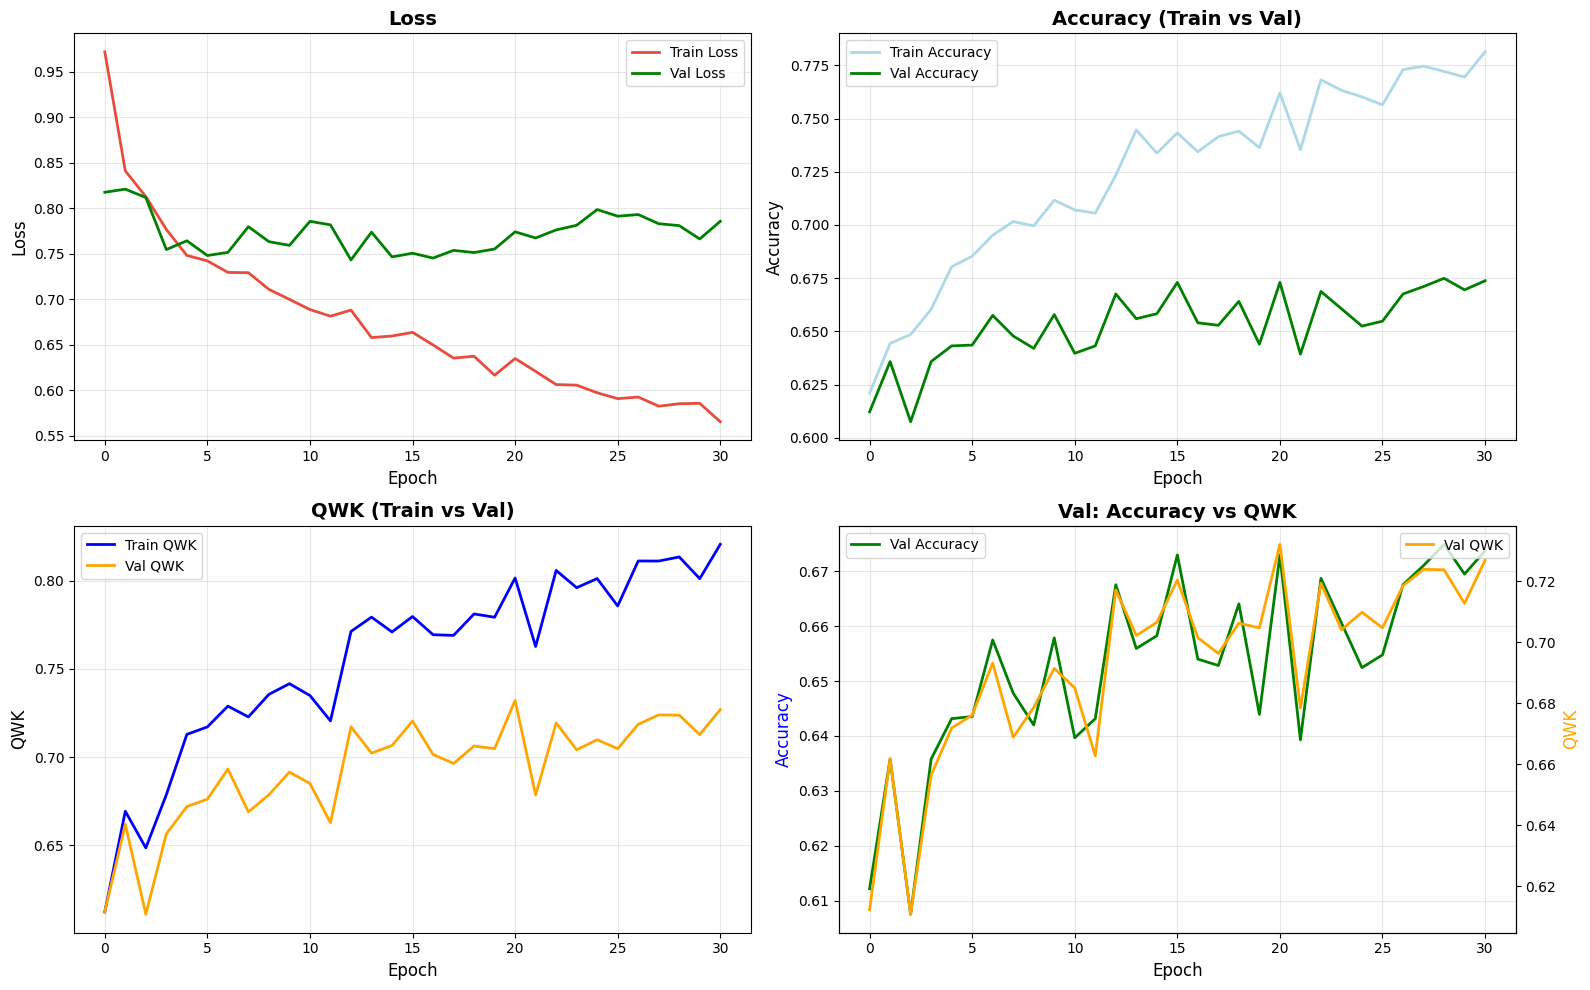

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Graphique 1: Train Loss + Val Loss
axes[0, 0].plot(history['train_loss'], linewidth=2, label='Train Loss', color='#e74c3c')
axes[0, 0].plot(history['val_loss'], linewidth=2, label='Val Loss', color='green')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title("Loss", fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Graphique 2: Train Acc + Val Acc
axes[0, 1].plot(history['train_acc'], linewidth=2, label='Train Accuracy', color='lightblue')
axes[0, 1].plot(history['val_acc'], linewidth=2, label='Val Accuracy', color='green')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Accuracy', fontsize=12)
axes[0, 1].set_title('Accuracy (Train vs Val)', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Graphique 3: Train QWK + Val QWK
axes[1, 0].plot(history['train_qwk'], linewidth=2, label='Train QWK', color='blue')
axes[1, 0].plot(history['val_qwk'], linewidth=2, label='Val QWK', color='orange')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('QWK', fontsize=12)
axes[1, 0].set_title('QWK (Train vs Val)', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Graphique 4: Comparaison Accuracy vs QWK (Val uniquement)
axes[1, 1].plot(history['val_acc'], linewidth=2, label='Val Accuracy', color='green')
ax2 = axes[1, 1].twinx()
ax2.plot(history['val_qwk'], linewidth=2, label='Val QWK', color='orange')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Accuracy', fontsize=12, color='blue')
ax2.set_ylabel('QWK', fontsize=12, color='orange')
axes[1, 1].set_title('Val: Accuracy vs QWK', fontsize=14, fontweight='bold')
axes[1, 1].legend(loc='upper left')
ax2.legend(loc='upper right')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 11.2 Évaluation sur Test


### 11.3 Résultats par Question

**Tableau détaillé** : QWK et Accuracy pour chaque question (1 à 10)

In [ ]:
from sklearn.metrics import accuracy_score

# Calcul des métriques par question
test_df_reset = test_df.reset_index(drop=True)
results_per_question = []

for q in range(1, 11):
    mask = test_df_reset['EssaySet'] == q
    if mask.sum() == 0:
        continue

    indices = mask[mask].index.tolist()
    y_true_q = y_test_true[indices]
    y_pred_q = y_test_pred[indices]

    acc_q = accuracy_score(y_true_q, y_pred_q)
    qwk_q = quadratic_weighted_kappa(y_true_q, y_pred_q)

    results_per_question.append({
        'Question': q,
        'Accuracy': acc_q,
        'QWK': qwk_q,
        'N_samples': len(y_true_q)
    })

results_df = pd.DataFrame(results_per_question)

# Affichage des résultats par question
print("\n- RÉSULTATS PAR QUESTION:")
print("=" * 70)
print(results_df.to_string(index=False))
print("=" * 70)

#  MÉTRIQUES FINALES
mean_accuracy = results_df['Accuracy'].mean()

print("\n RÉSULTATS FINAUX")
print("=" * 40)
print(f"   Accuracy globale : {test_acc:.4f}")
print(f"   QWK Global    : {test_qwk:.4f} ")
print("=" * 40)



- RÉSULTATS PAR QUESTION:
 Question  Accuracy      QWK  N_samples
        1  0.506024 0.652163        249
        2  0.439024 0.465059        205
        3  0.498305 0.039958        295
        4  0.726531 0.555123        245
        5  0.830935 0.671701        278
        6  0.896194 0.787476        289
        7  0.734982 0.628510        283
        8  0.646586 0.581037        249
        9  0.684615 0.673698        260
       10  0.746725 0.620723        229

 RÉSULTATS FINAUX
   Accuracy globale : 0.6774
   QWK Global    : 0.7155 


### 11.4 Comparaison avec l'État de l'Art

In [ ]:
# Tableau comparatif
comparison = pd.DataFrame({
    'Modèle': ['CharCNN (2019)', 'CNN (2019)', 'Bi-LSTM (2019)', 'BERT (2019)',
               'GPT-4 (2024)', 'Notre Modèle'],
    'QWK': [0.60, 0.62, 0.65, 0.71, 0.677, test_qwk],
    'Accuracy': ['-', '-', '-', '-', 0.716, test_acc]
})

print("\n COMPARAISON AVEC L'ÉTAT DE L'ART")
print("="*70)
print(comparison.to_string(index=False))
print("="*70)

if test_qwk > 0.71:
    print(f"\n✅ OBJECTIF ATTEINT ! Amélioration: +{(test_qwk - 0.71):.4f}")
    print("   Notre modèle surpasse BERT (état de l'art 2019)")
elif test_qwk > 0.65:
    print(f"\n- Bon résultat ! QWK = {test_qwk:.4f}")
    print(f"   Écart à BERT: {(0.71 - test_qwk):.4f}")
else:
    print(f"\n QWK = {test_qwk:.4f}")
    print(f"   Écart à BERT: {(0.71 - test_qwk):.4f}")


 COMPARAISON AVEC L'ÉTAT DE L'ART
        Modèle      QWK  Accuracy
CharCNN (2019) 0.600000         -
    CNN (2019) 0.620000         -
Bi-LSTM (2019) 0.650000         -
   BERT (2019) 0.710000         -
  GPT-4 (2024) 0.677000     0.716
  Notre Modèle 0.715455  0.677382

✅ OBJECTIF ATTEINT ! Amélioration: +0.0055
   Notre modèle surpasse BERT (état de l'art 2019)


### 11.5 Visualisation Performance par Question

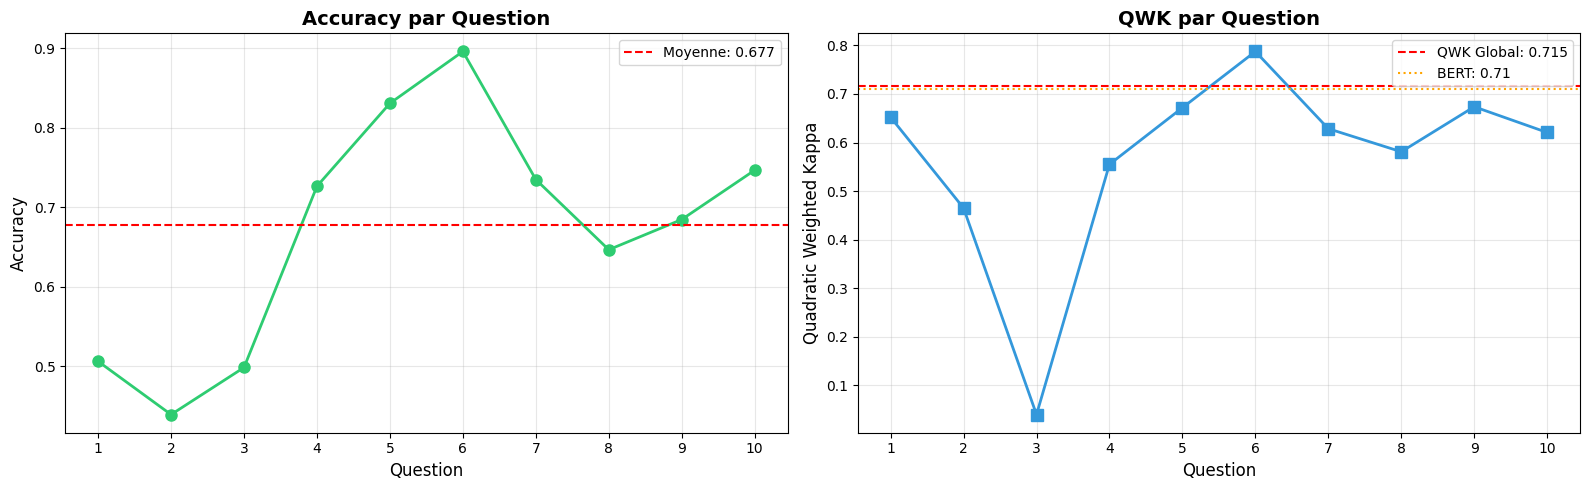

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy par question
axes[0].plot(results_df['Question'], results_df['Accuracy'], 'o-', linewidth=2, markersize=8, color='#2ecc71')
axes[0].axhline(y=test_acc, color='r', linestyle='--', label=f'Moyenne: {test_acc:.3f}')
axes[0].set_xlabel('Question', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy par Question', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(1, 11))
axes[0].legend()
axes[0].grid(alpha=0.3)

# QWK par question
axes[1].plot(results_df['Question'], results_df['QWK'], 's-', linewidth=2, markersize=8, color='#3498db')
axes[1].axhline(y=test_qwk, color='r', linestyle='--', label=f'QWK Global: {test_qwk:.3f}')
axes[1].axhline(y=0.71, color='orange', linestyle=':', label='BERT: 0.71')
axes[1].set_xlabel('Question', fontsize=12)
axes[1].set_ylabel('Quadratic Weighted Kappa', fontsize=12)
axes[1].set_title('QWK par Question', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(1, 11))
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 11.6 Matrice de Confusion

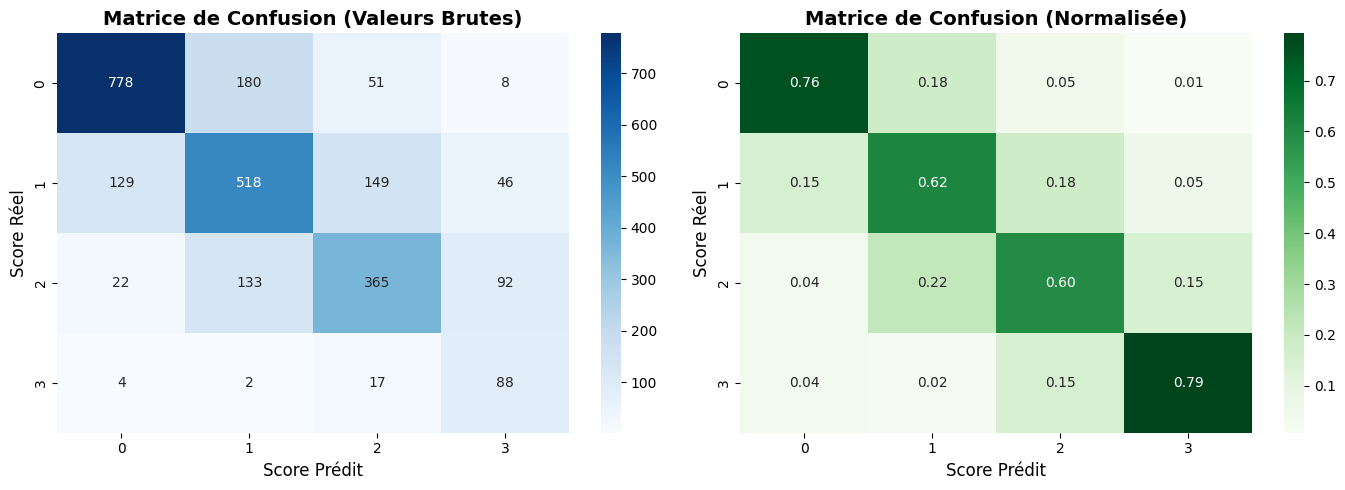

In [ ]:
# Matrice de confusion
cm = confusion_matrix(y_test_true, y_test_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice brute
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=sorted(df['Score1'].unique()),
            yticklabels=sorted(df['Score1'].unique()))
axes[0].set_xlabel('Score Prédit', fontsize=12)
axes[0].set_ylabel('Score Réel', fontsize=12)
axes[0].set_title('Matrice de Confusion (Valeurs Brutes)', fontsize=14, fontweight='bold')

# Matrice normalisée
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=sorted(df['Score1'].unique()),
            yticklabels=sorted(df['Score1'].unique()))
axes[1].set_xlabel('Score Prédit', fontsize=12)
axes[1].set_ylabel('Score Réel', fontsize=12)
axes[1].set_title('Matrice de Confusion (Normalisée)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 11.7 Exemples de Prédictions

**10 exemples aléatoires** pour évaluer qualitativement le modèle

In [ ]:
# Sélection d'exemples aléatoires
np.random.seed(42)
random_indices = np.random.choice(len(test_df_reset), size=10, replace=False)

print("📝 EXEMPLES DE PRÉDICTIONS")
print("="*100)

for i, idx in enumerate(random_indices, 1):
    question = test_df_reset.iloc[idx]['EssaySet']
    text = test_df_reset.iloc[idx]['EssayText_clean'][:120]
    real = y_test_true[idx]
    pred = y_test_pred[idx]

    status = "✅" if real == pred else "❌"

    print(f"\n{status} Exemple {i} | Question {question}")
    print(f"   Texte: {text}...")
    print(f"   Score réel: {real} | Score prédit: {pred}")
    print("-" * 100)

# Statistiques
correct = (y_test_true == y_test_pred).sum()
total = len(y_test_true)
print(f"\n-> Bilan: {correct}/{total} prédictions correctes ({correct/total*100:.1f}%)")

📝 EXEMPLES DE PRÉDICTIONS

✅ Exemple 1 | Question 8
   Texte: When Paul realised who Mr. Leonard was, he related his situation to his. Mr. Leonard and Paul were in the same boat. Onl...
   Score réel: 1 | Score prédit: 1
----------------------------------------------------------------------------------------------------

✅ Exemple 2 | Question 5
   Texte: First, the newly formed mRNA branches away from the stand of DNA. Second, the information carried by the mRNA is transpo...
   Score réel: 0 | Score prédit: 0
----------------------------------------------------------------------------------------------------

✅ Exemple 3 | Question 4
   Texte: I think the significance of the word invasive means that the animals don't belong like and they are not like introduced ...
   Score réel: 0 | Score prédit: 0
----------------------------------------------------------------------------------------------------

✅ Exemple 4 | Question 9
   Texte: The author of this article organizes it into four 

---
## 12. Sauvegarde du Modèle

**Fichiers sauvegardés** :
- `best_model.pth` : Poids du modèle PyTorch
- `model_metadata.pkl` : Métadonnées pour Streamlit

In [ ]:
import pickle

# Métadonnées
metadata = {
    'sbert_model_name': 'all-mpnet-base-v2',
    'num_classes': num_classes,
    'question_info': {
        q: {
            'n_classes': df[df['EssaySet'] == q]['Score1'].nunique(),
            'scores': sorted(df[df['EssaySet'] == q]['Score1'].unique().tolist())
        }
        for q in range(1, 11)
    },
    'performance': {
        'test_qwk': test_qwk,
        'test_accuracy': test_acc,
        'results_per_question': results_df.to_dict('records')
    }
}

with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print("✅ Modèle sauvegardé:")
print("   - best_model.pth (poids PyTorch)")
print("   - model_metadata.pkl (métadonnées)")

# Télécharger
from google.colab import files
files.download('best_model.pth')
files.download('model_metadata.pkl')

✅ Modèle sauvegardé:
   - best_model.pth (poids PyTorch)
   - model_metadata.pkl (métadonnées)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>